## Experiment Controls

In [1]:
STATE_NAME = 'missouri'
ACCEPT_STRATEGY_NAME = 'neutral' # 'neutral', 'optimized', 'unoptimized'
WEIGHTS_FILE = 'test_weights'
MARKOV_STEPS = 100_000
DESIRED_TCP = 0.56

In [2]:
# Parameters
STATE_NAME = "missouri"
ACCEPT_STRATEGY_NAME = "unoptimized"
WEIGHTS_FILE = "test_weights"
MARKOV_STEPS = 500000
DESIRED_TCP = 0.56


## Imports

In [3]:
# pip install numpy pandas geopandas matplotlib networkx gerrychain jinja2 nbformat papermill

In [4]:
%load_ext autoreload
%autoreload 2
## path setup
import sys
import os
# go up a level to main proj folder
parent_dir = os.path.abspath('..')
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

from common import scoring
from common import plotting
from common import acceptance


In [5]:
from IPython.display import display

import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from scipy.stats import pearsonr
import networkx as nx

from gerrychain import (Partition, Graph, updaters, MarkovChain, constraints, accept)
from gerrychain.accept import always_accept
from gerrychain.proposals import recom
from gerrychain.constraints import contiguous
from gerrychain.updaters import cut_edges
from gerrychain.tree import recursive_tree_part
from functools import partial

import json
import random

## Process Initial Data

### Census-Level Precinct Data + Community Data

In [6]:
# read voter district map and mggg community cluster map
vtds = gpd.read_file("data/mo-aggregated/mo.shp")
cois = gpd.read_file("data/mo_2021_coi/MO_20210924_phase_C_summary.shp")

# find subclusters to drop parents
subclusters = cois[cois['cluster'].str.contains('-')]
parents_to_drop = subclusters['cluster'].apply(lambda x: x.split('-')[0]).unique()
cois = cois[~cois['cluster'].isin(parents_to_drop)]

# align coords on both maps
if cois.crs != vtds.crs:
    vtds = vtds.to_crs(cois.crs)

## get total presidential election 2020 vote pop
vtds['TOTVOTES20'] = vtds['PRE20D'] + vtds['PRE20R'] + vtds['PRE20O']

## now need coi fractions per vtd
# what fraction of community resides here? coi area / total area
vtds['vtd_area'] = vtds.geometry.area
overlaps = gpd.overlay(vtds, cois, how='intersection')
overlaps['coi_fraction'] = overlaps.geometry.area / overlaps['vtd_area']

# drop tiny overlaps
clean_overlaps = overlaps[overlaps['coi_fraction'] > 0.01].copy()

# figure out num people from overlaps pct
clean_overlaps['coi_pop'] = clean_overlaps['TOTPOP'] * clean_overlaps['coi_fraction']

# build coi pop dict per vtd
coi_dict = {}
for index, row in clean_overlaps.iterrows():
    vtd_name = row['NAME20']
    cluster_id = row['cluster']
    population_chunk = row['coi_pop']
    
    if vtd_name not in coi_dict:
        coi_dict[vtd_name] = {}
        
    coi_dict[vtd_name][cluster_id] = {
        'pop': population_chunk,
        'category': row.get('predicted_category', 'coi') # 'coi is default unweighted
    }

vtds['COI_POPS'] = [coi_dict.get(name, {}) for name in vtds['NAME20']]


### Add District Data from Congressional Maps - 2022, 2025

In [7]:
## add enacted maps - gives district 
congressional_2025 = gpd.read_file("data/mo_2025_congressional/HB1_Cong_Dist_2025.shp")
congressional_2022 = gpd.read_file('data/mo_2022_congressional/tl_2022_29_cd118.shp')

congressional_2025 = congressional_2025.to_crs(vtds.crs)
congressional_2022 = congressional_2022.to_crs(vtds.crs)

# get center vtd points to map to congressional districts
vtd_points = vtds.copy()
vtd_points.geometry = vtd_points.representative_point()

joined_vtds_2025 = gpd.sjoin(vtd_points, congressional_2025, how="left", predicate="intersects")
joined_vtds_2022 = gpd.sjoin(vtd_points, congressional_2022, how="left", predicate="intersects")

vtds['district_2025'] = joined_vtds_2025['District']
vtds['district_2022'] = joined_vtds_2022['CD118FP'].astype(int)


## Markov Chaining

### Init Graph and Chain

In [8]:
## init graph
vtds.geometry = vtds.geometry.buffer(0)
g = Graph.from_geodataframe(vtds)

# put control vars on graph 
with open(f'../weights/{WEIGHTS_FILE}.json', 'r') as f:
    state_weights = json.load(f)

g.graph['DESIRED_TCP'] = DESIRED_TCP
g.graph['WEIGHT_MAP'] = state_weights

# missouri has 8 districts
total_population = sum(node.get('TOTPOP', 1) for node in g.nodes.values())
target_pop = total_population / 8

# using a gerrychain method to start with 8 equal nice contiguous parts
starting_assignment = recursive_tree_part(
    g, 
    parts=range(8), 
    pop_target=target_pop, 
    pop_col="TOTPOP", 
    epsilon=0.05
)

updaters_dict = { 
    'raw_df': scoring.extract_data, 
    'unweighted_tcp_score': scoring.calculate_unweighted_tcp,
    'weighted_tcp_score': scoring.calculate_weighted_tcp,
    'communities_split': scoring.communities_split,
    'effective_splits': scoring.effective_splits,
    'sr_entropy': scoring.square_root_entropy,
    'shannon_entropy': scoring.shannon_entropy,
    'even_splits': scoring.even_splits,
    'cut_edges': cut_edges,
    'dem_wins': scoring.count_dem_wins,
    'dem_share': scoring.dem_share,
    'dem_box': scoring.dem_boxes
}

## init part
initial_partition = Partition(
    g, 
    assignment=starting_assignment, 
    updaters=updaters_dict
)

## init chain
proposal = partial(recom, pop_col="TOTPOP", pop_target=target_pop, epsilon=0.05, node_repeats=2)
accept_function = acceptance.STRATEGIES.get(ACCEPT_STRATEGY_NAME, always_accept)
chain = MarkovChain(
    proposal=proposal,
    constraints=[],
    accept=accept_function,
    initial_state=initial_partition,
    total_steps=MARKOV_STEPS
)

### Run Chain

In [9]:
# collect scores
num_districts = len(initial_partition.parts)

chain_results = {
    'step': [],
    'weighted_tcp_score': [],
    'unweighted_tcp_score': [],
    'communities_split': [],
    'effective_splits': [],
    'sr_entropy': [],
    'shannon_entropy': [],
    'even_splits': [],
    'cut_edges': [],
    'dem_wins': []
}
# district share columns
for i in range(1, num_districts + 1):
    chain_results[f'dist_{i}_dem_share'] = []

# map tracking
best_score=0
best_map=None
worst_score=1
worst_map=None
overall_best_score=0
overall_best_map=None
most_seats=0

# all tcp scores grouped by seat count
tcp_scores_by_seats = {seat_count: [] for seat_count in range(9)}

for step, partition in enumerate(chain):
    if step > 0 and step % (MARKOV_STEPS // 10 or 1) == 0:
        print(f"completed {step} steps...")

    weighted_score = partition['weighted_tcp_score']
    seats = partition['dem_wins']
    shares = partition['dem_share']

    chain_results['step'].append(step)
    chain_results['weighted_tcp_score'].append(weighted_score)
    chain_results['unweighted_tcp_score'].append(partition['unweighted_tcp_score'])
    chain_results['communities_split'].append(partition['communities_split'])
    chain_results['effective_splits'].append(partition['effective_splits'])
    chain_results['sr_entropy'].append(partition['sr_entropy'])
    chain_results['shannon_entropy'].append(partition['shannon_entropy'])
    chain_results['even_splits'].append(partition['even_splits'])
    chain_results['cut_edges'].append(len(partition['cut_edges']))
    chain_results['dem_wins'].append(seats)
    # dem share per district
    for i in range(num_districts):
        chain_results[f'dist_{i+1}_dem_share'].append(shares[i])
    # append scores under its seat count 
    tcp_scores_by_seats[seats].append(weighted_score)

    # track most preserved
    if weighted_score > best_score:
        best_score = weighted_score
        best_map = partition

    # track least preserved
    if weighted_score < worst_score:
        worst_score = weighted_score
        worst_map = partition

    # track max minority seats, best score
    if seats > most_seats:
        most_seats = seats
        overall_best_score = weighted_score
        overall_best_map = partition
    elif seats == most_seats:
        if weighted_score > overall_best_score:
            overall_best_score = weighted_score
            overall_best_map = partition

# save to csv
results_df = pd.DataFrame(chain_results)

k_str = f"{int(MARKOV_STEPS/1000)}k" if MARKOV_STEPS >= 1000 else str(MARKOV_STEPS)
base_filename = f"data/{STATE_NAME}_{ACCEPT_STRATEGY_NAME}_{WEIGHTS_FILE}_{k_str}"
csv_filename = f"{base_filename}.csv"

if os.path.exists(csv_filename):
    version = 1
    new_filename = f"{base_filename}_v{version}.csv"
    while os.path.exists(new_filename):
        version += 1
        new_filename = f"{base_filename}_v{version}.csv"
    csv_filename = new_filename
results_df.to_csv(csv_filename, index=False)
print(f"saved chain data to: {csv_filename}")

completed 50000 steps...


completed 100000 steps...


completed 150000 steps...


completed 200000 steps...


completed 250000 steps...


...

completed 350000 steps...


/Users/jevonlipsey/miniconda3/envs/mcure/lib/python3.12/site-packages/gerrychain/tree.py:704: BipartitionWarning: 
Failed to find a balanced cut after 1000 attempts.
If possible, consider enabling pair reselection within your
MarkovChain proposal method to allow the algorithm to select
a different pair of districts for recombination.
  warnings.warn(


completed 400000 steps...


completed 450000 steps...


saved chain data to: data/missouri_unoptimized_test_weights_500k.csv


## Maps

In [10]:
# score enacted maps for plotting
enacted_2022 = Partition(
    g,
    assignment="district_2022",
    updaters=updaters_dict
)

enacted_2025 = Partition(
    g,
    assignment="district_2025",
    updaters=updaters_dict
)

### Congressional Maps - 2022, 2025

In [11]:
plotting.plot_partition_detailed(enacted_2025, vtds, cois, title="2025 Enacted Map")
plotting.plot_partition_detailed(enacted_2022, vtds, cois, title="2025 Enacted Map")

### Markov Chain Saved Maps

In [1]:
plotting.plot_partition_detailed(best_map, vtds, cois, title="Most Preserved Map")
plotting.plot_partition_detailed(overall_best_map, vtds, cois, title="Overall Best Map")
plotting.plot_partition_detailed(worst_map, vtds, cois, title="Worst Preserved Map")

NameError: name 'plotting' is not defined

#### Check Individual Community Scores

In [13]:
formatter = {'total_pop': '{:,.0f}', 'sss_score': '{:.4f}'}

scores_2022 = scoring.score_communities(enacted_2022['raw_df'])
scores_2025 = scoring.score_communities(enacted_2025['raw_df'])

print("The 10 Most Fractured Communities in 2022:")
display(scores_2022.sort_values(by='sss_score').head(10).style.format(formatter))

print("The 10 Most Preserved Communities in 2022:")
display(scores_2022.sort_values(by='sss_score').tail(10).style.format(formatter))

print("The 10 Most Fractured Communities in 2025:")
display(scores_2025.sort_values(by='sss_score').head(10).style.format(formatter))

print("The 10 Most Preserved Communities in 2025:")
display(scores_2025.sort_values(by='sss_score').tail(10).style.format(formatter))

The 10 Most Fractured Communities in 2022:


,category,community_id,total_pop,sss_score
0,coi,C1,"2,261,472",0.2680
33,coi,C6,"232,161",0.2778
28,coi,C33,"198,195",0.2924
34,coi,C7,"618,178",0.3354
30,coi,C35,"241,169",0.3586
2,coi,C11,"167,217",0.3754
12,coi,C20,"564,181",0.4427
1,coi,C10,"259,508",0.4524
4,coi,C13,"1,183,054",0.4852
14,coi,C21-2,"107,742",0.4938


The 10 Most Preserved Communities in 2022:


,category,community_id,total_pop,sss_score
31,coi,C4,"100,479",0.9259
27,coi,C32,"76,639",0.9447
35,coi,C8,"195,605",0.9659
29,coi,C34,"63,158",0.9700
22,coi,C28,"27,032",1.0000
16,coi,C23,"14,556",1.0000
6,coi,C15,"235,472",1.0000
3,coi,C12,"88,670",1.0000
24,coi,C3,"191,555",1.0000
11,coi,C2,"86,280",1.0000


The 10 Most Fractured Communities in 2025:


,category,community_id,total_pop,sss_score
0,coi,C1,"2,261,472",0.2700
33,coi,C6,"232,161",0.2778
28,coi,C33,"198,195",0.2947
4,coi,C13,"1,183,054",0.3323
15,coi,C22,"167,447",0.3757
27,coi,C32,"76,639",0.3770
30,coi,C35,"241,169",0.3947
12,coi,C20,"564,181",0.4576
7,coi,C16,"429,529",0.4604
6,coi,C15,"235,472",0.4607


The 10 Most Preserved Communities in 2025:


,category,community_id,total_pop,sss_score
5,coi,C14,"305,796",0.8290
9,coi,C18,"152,576",0.8510
23,coi,C29,"203,817",0.8866
17,coi,C24,"136,769",0.8917
31,coi,C4,"100,479",0.9085
29,coi,C34,"63,158",0.9700
22,coi,C28,"27,032",1.0000
16,coi,C23,"14,556",1.0000
11,coi,C2,"86,280",1.0000
24,coi,C3,"191,555",1.0000


## Plots

In [14]:
enacted_reference_data = {
    "2022 Enacted": {
        "score": enacted_2022["weighted_tcp_score"], 
        "wins": enacted_2022["dem_wins"]
    },
    "2025 Enacted": {
        "score": enacted_2025["weighted_tcp_score"], 
        "wins": enacted_2025["dem_wins"]
    }
}

initial_score = initial_partition["weighted_tcp_score"]
initial_wins = initial_partition["dem_wins"]

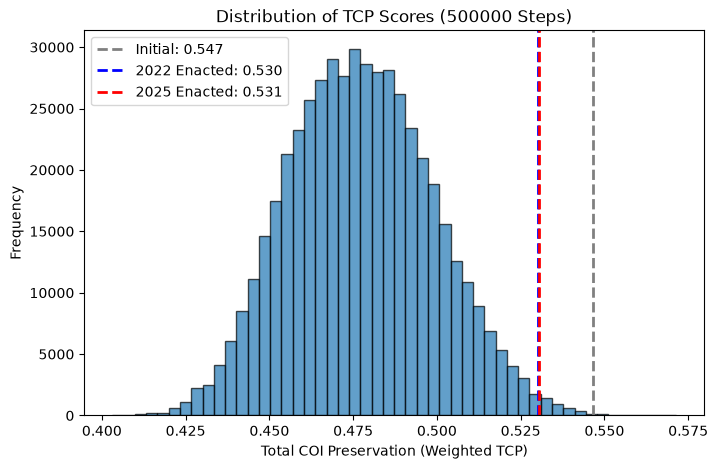

In [15]:
# hist: tcp scores distribution
plotting.plot_tcp_distribution(
    results_df, 
    initial_score=initial_score, 
    enacted_data=enacted_reference_data, 
    steps_str=str(MARKOV_STEPS)
)

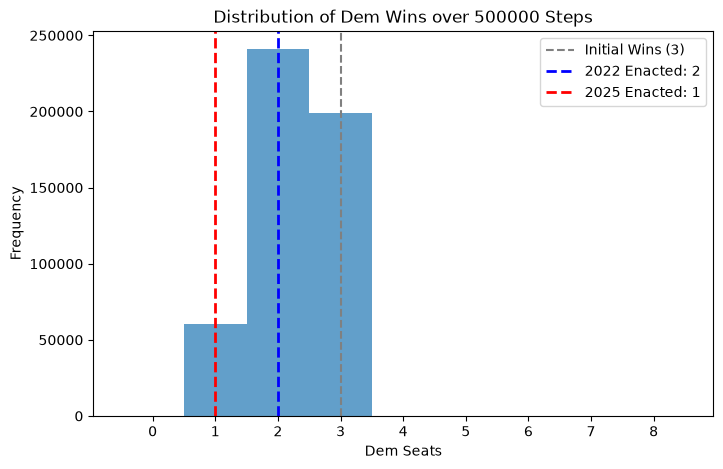

In [16]:
# hist: dem seats distribution
plotting.plot_dem_wins_distribution(
    results_df, 
    initial_wins=initial_wins, 
    enacted_data=enacted_reference_data, 
    steps_str=str(MARKOV_STEPS)
)

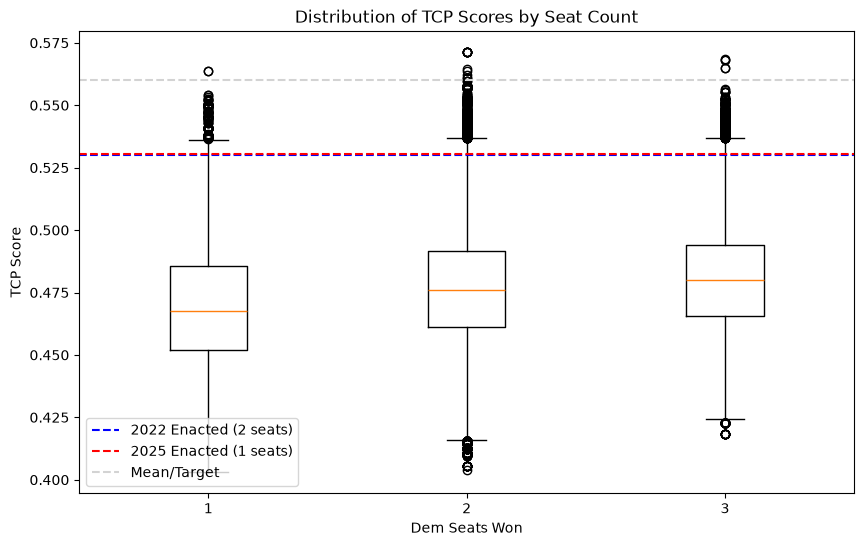

In [17]:
# boxplot: tcp scores by seat count
plotting.plot_tcp_by_seat_count(
    results_df, 
    enacted_data=enacted_reference_data, 
    desired_tcp=DESIRED_TCP
)

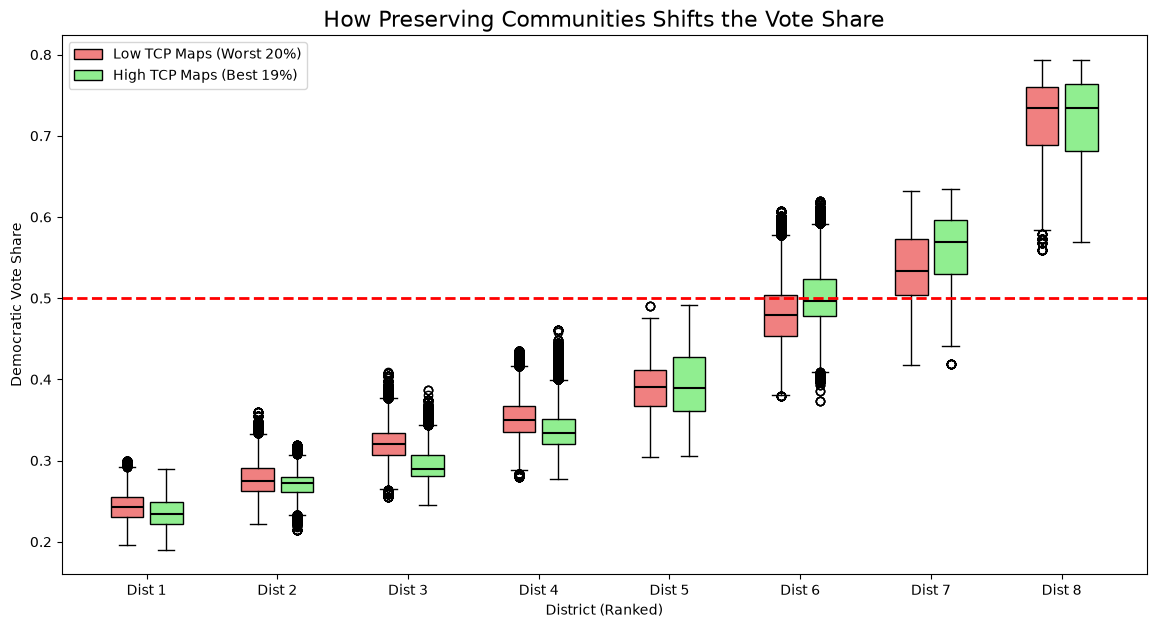

In [18]:
# boxplot: partisan shift - tcp vs dem share per district
plotting.plot_partisan_shift(
    results_df, 
    score_col='weighted_tcp_score', 
    top_q=0.80, 
    bottom_q=0.20
)

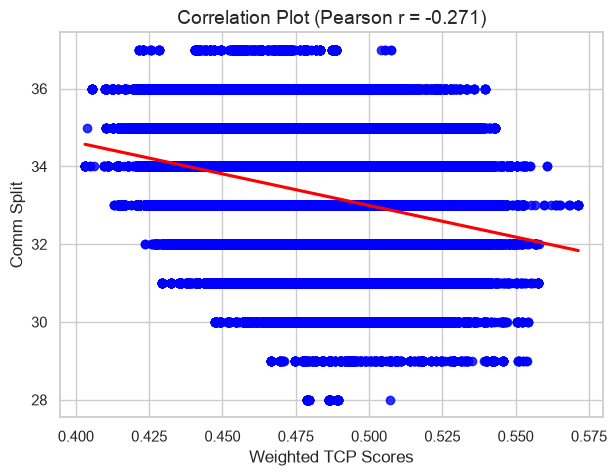

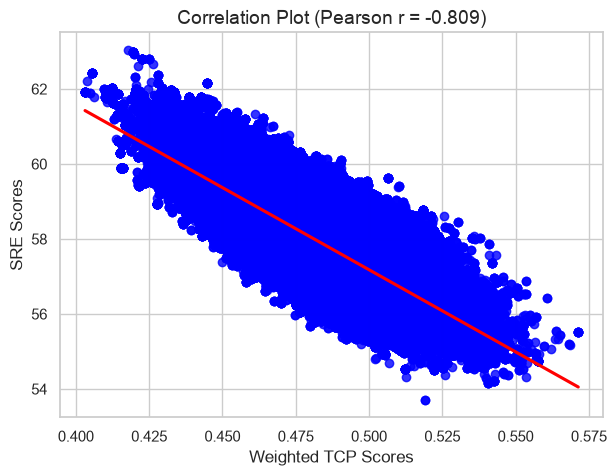

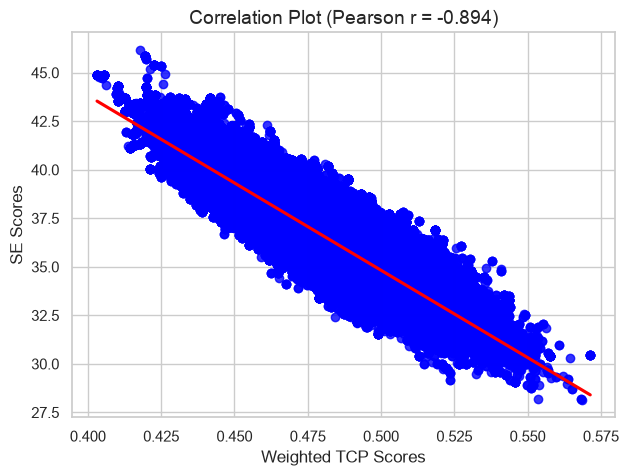

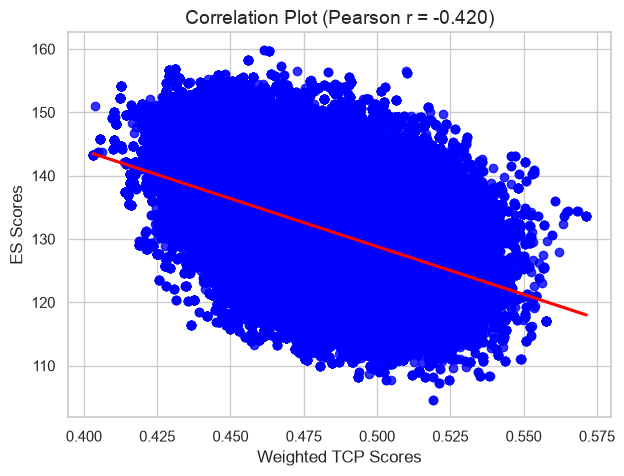

In [19]:
## correlation scatters
metrics_to_correlate = [
    ('communities_split', 'Comm Split'),
    ('sr_entropy', 'SRE Scores'),
    ('shannon_entropy', 'SE Scores'),
    ('even_splits', 'ES Scores')
]

sns.set_theme(style="whitegrid")
for metric_col, label in metrics_to_correlate:
    corr_coef, _ = pearsonr(results_df['weighted_tcp_score'], results_df[metric_col])
    
    plt.figure(figsize=(7, 5))
    sns.regplot(
        data=results_df, 
        x='weighted_tcp_score', 
        y=metric_col, 
        scatter_kws={"color": "blue"}, 
        line_kws={"color": "red"}, 
        marker="o"
    )
    plt.title(f"Correlation Plot (Pearson r = {corr_coef:.3f})", fontsize=14)
    plt.xlabel("Weighted TCP Scores")
    plt.ylabel(label)
    plt.show()